### Data Generation for frustrated lattices (Heisenberg J1-J2 models)

In [3]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,
)

In [4]:
import matplotlib.pyplot as plt
from itertools import product
import igraph as ig
import numpy as np
from collections import defaultdict
from bitarray.util import int2ba
import pandas as pd
import seaborn as sns
import lattice_symmetries as ls
from more_itertools import sliced
import yaml

from spin_lattice_gen import SpinLattice

%matplotlib inline

In [102]:
def make_unpacked_configurations(states, number_spins):
    return (
        (np.arange(2**number_spins).reshape(-1, 1) >> np.arange(number_spins)) & 1
    )[states]

In [167]:
class HeisenbergJ1J2:
    def __init__(
        self,
        lat: SpinLattice,
        J1: float = 1.0,
        J2: float = 1.0,
        use_symmetries=True,
        spin_inversion=1,
    ):
        self.lat = lat

        self.number_spins = len(lat.sites)  # System size

        print(f"{self.number_spins=}")
        hamming_weight = (
            self.number_spins // 2
        )  # Hamming weight (i.e. number of spin ups)

        # Constructing symmetries

        if use_symmetries:
            symmetries = [
                ls.Symmetry(automorphism, sector=0)
                for automorphism in lat.get_automorphisms()
            ]
        else:
            symmetries = []

        # Constructing the group
        self.symmetry_group = ls.Group(symmetries)
        print("Symmetry group contains {} elements".format(len(self.symmetry_group)))

        # Constructing the basis
        self.basis = ls.SpinBasis(
            self.symmetry_group,
            number_spins=self.number_spins,
            hamming_weight=hamming_weight,
            spin_inversion=spin_inversion,
        )
        self.basis.build()  # Build the list of representatives, we need it since we're doing ED
        print("Hilbert space dimension is {}".format(self.basis.number_states))

        self.canonical_basis = ls.SpinBasis(
            ls.Group([]),
            number_spins=self.number_spins,
            hamming_weight=hamming_weight,
            spin_inversion=None,
        )

        # this can probably be optimized / avoided
        self.canonical_basis.build()

        # Heisenberg Hamiltonian
        # fmt: off
        σ_x = np.array([ [0, 1]
                       , [1, 0] ])
        σ_y = np.array([ [0 , -1j]
                       , [1j,   0] ])
        σ_z = np.array([ [1,  0]
                       , [0, -1] ])
        # fmt: on
        σ_p = σ_x + 1j * σ_y
        σ_m = σ_x - 1j * σ_y

        matrix = 0.5 * (np.kron(σ_p, σ_m) + np.kron(σ_m, σ_p)) + np.kron(σ_z, σ_z)

        self.hamiltonian = ls.Operator(
            self.basis,
            [
                ls.Interaction(J * matrix, edges)
                for J, (_, edges) in zip([J1, J2], sorted(lat.kind_to_edges.items()))
            ],
        )

        self.ground_state = None
        self.ground_energy = None

    def unpack_configurations(self):
        """
        Unpacks all configurations in the basis into an np.array
        of one-dimensional np.arrays with 0's and 1's
        """
        return make_unpacked_configurations(self.basis.states, self.number_spins)

    def get_ground_state(self, k=1) -> tuple[np.array, np.array]:
        """
        Records ground_energy and ground_state into to self.ground_energy and self.ground_state
        (only one value, the smallest energy) and returns k smallest eigenvalue / eigenvectors

        Returns
        -------
        eigenvalues : np.array
            k smallest eigenvalues

        eigenstates : np.array
            k eigenvectors (as vector-columns) corresponding to the k smalles eigenvalues

        """
        # Diagonalize the Hamiltonian using ARPACK
        eigenvalues, eigenstates = ls.diagonalize(self.hamiltonian, k=k)
        print("Ground state energy is {:.10f}".format(eigenvalues[0]))

        self.ground_energy = eigenvalues[0]
        self.ground_state = eigenstates[:, 0]

        return eigenvalues, eigenstates
        # assert np.isclose(eigenvalues[0], -18.06178542)

    def get_df_ground_state(
        self,
        unpack_configurations=False,
        expand_basis_columns=False,
        canonical_basis=False,
    ) -> pd.DataFrame:
        """
        Returns the dataframe with two columns: unpacked configuration and the corresponding
        value in the ground state
        """
        if self.ground_state is None:
            raise ValueError("Ground State not found; run .get_ground_state() first")

        df = pd.DataFrame(
            dict(basis_state=self.basis.states, ground_state_coeff=self.ground_state)
        )

        if canonical_basis:
            df = self.transform_df_to_canonical(df)

        df["amplitude"] = np.abs(df["ground_state_coeff"])

        if unpack_configurations:
            unpacked_configurations = make_unpacked_configurations(
                df["basis_state"], self.number_spins
            )
            if expand_basis_columns:
                spins_df = pd.DataFrame(
                    unpacked_configurations,
                    columns=[f"s{i}" for i in range(self.number_spins)],
                )
            else:
                spins_df = pd.DataFrame(
                    dict(configuration=list(unpacked_configurations))
                )
            return df.join(spins_df)

        return df

    def transform_df_to_canonical(self, df):
        def pad_right(arr, n):
            # Pad the array with zeros to the left to create an n x 8 matrix
            arr = arr.reshape(-1, 1)
            return np.pad(arr, [(0, 0), (0, n - 1)], "constant", constant_values=0)

        assert (
            pad_right(np.array([1, 2, 3]), 8)
            == np.array(
                [
                    [1, 0, 0, 0, 0, 0, 0, 0],
                    [2, 0, 0, 0, 0, 0, 0, 0],
                    [3, 0, 0, 0, 0, 0, 0, 0],
                ]
            )
        ).all()

        def my_batched_state_info(basis, bits):
            representative, eigenvalue, norm = basis.batched_state_info(
                pad_right(bits, 8)
            )
            representative = representative[:, 0]
            return representative, eigenvalue, norm

        representative, eigenvalue, norm = my_batched_state_info(
            self.basis, self.canonical_basis.states
        )

        state_info_df = pd.DataFrame(
            dict(
                basis_state=self.canonical_basis.states,
                representative=representative,
                character=eigenvalue,
                norm=norm,
            )
        )

        return (
            state_info_df.merge(df, left_on="representative", right_on="basis_state")
            .assign(
                ground_state_adjusted=lambda x: np.real_if_close(
                    x["ground_state_coeff"] * x["character"] * x["norm"]
                )
            )
            .drop(
                [
                    "ground_state_coeff",
                    "basis_state_y",
                    "representative",
                    "character",
                    "norm",
                ],
                axis=1,
            )
            .rename(
                columns={
                    "ground_state_adjusted": "ground_state_coeff",
                    "basis_state_x": "basis_state",
                }
            )
        )

    def visualize_probable_configurations(self, k=0):
        """
        Visualizes k'th most probable configuration
        """
        df = self.get_df_ground_state(unpack_configurations=True).sort_values(
            "amplitude", ascending=False
        )
        self.lat.plot(spins=df.iloc[k]["configuration"])
        plt.title(
            f"Plotted {k}'s most probable state, wavefunction value = {df.iloc[k]['ground_state_coeff']}"
        )

#### Chain Lattice (1dim)

In [168]:
class ChainLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        """

        A ----- B

        Size of the fundamentail domain is 1×0
        """
        u = np.array([1, 0])
        v = np.array([0, 1])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
        }

        named_edges = [
            ("AB", 1),
        ]

        super().__init__(
            u=u,
            v=v,
            named_sites=named_sites,
            named_edges=named_edges,
            fundamental_domain_size=np.array([1, 1]),
            width=width,
            height=height,
        )

self.number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 924
Ground state energy is -21.5495636698


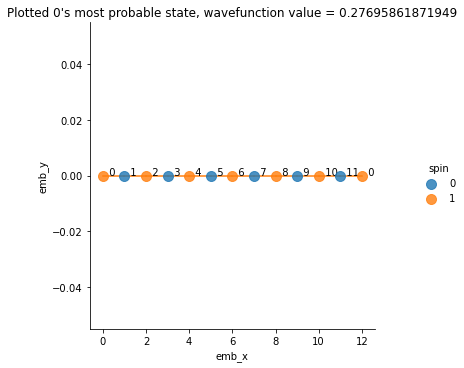

In [169]:
system_nosym = HeisenbergJ1J2(
    ChainLattice(width=12), J1=1, J2=0, use_symmetries=False, spin_inversion=None
)
energy, state = system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

Antiferromagnetic, as expected

self.number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 35
Ground state energy is -21.5495636698


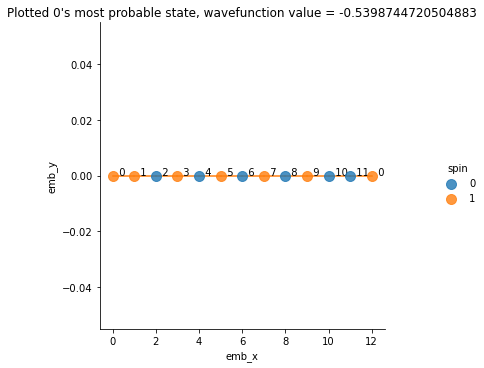

In [112]:
system_sym = HeisenbergJ1J2(ChainLattice(width=12), J1=1, J2=0, use_symmetries=True)
energy, state = system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

### NB
The “most probable configuration” is not physically defined: we change it when we take symmetries into account (collapse several events into one). So the result is different for calculations with symmetries and without them.

In [113]:
class SquareLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        """
        Generates square J1-J2 lattice.

        The fundamental domain:

        C ----- D
        | \\ // |
        |  \V/  |
        |  /Ʌ\  |
        | // \\ |
        A ----- B

        Size of the fundamentail domain is 1×1
        """
        u = np.array([1, 0])
        v = np.array([0, 1])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([0, 1]),
            "D": np.array([1, 1]),
        }

        named_edges = [("AB", 1), ("AC", 1), ("CD", 1), ("BD", 1), ("CB", 2), ("AD", 2)]

        super().__init__(
            u=u,
            v=v,
            named_sites=named_sites,
            named_edges=named_edges,
            fundamental_domain_size=1,
            width=width,
            height=height,
        )

### Checks

#### 4×4 SquareLattice, J2=0

self.number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Ground state energy is -44.9139328337


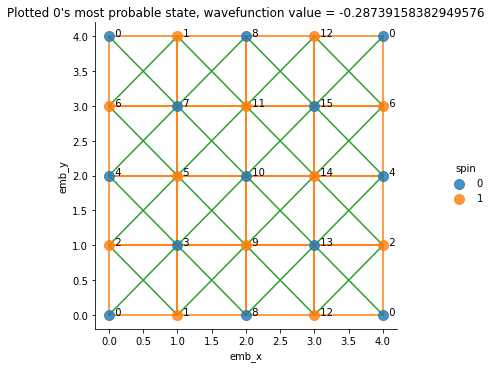

In [114]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

The checkerboard, works as expected

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Ground state energy is -44.9139328337


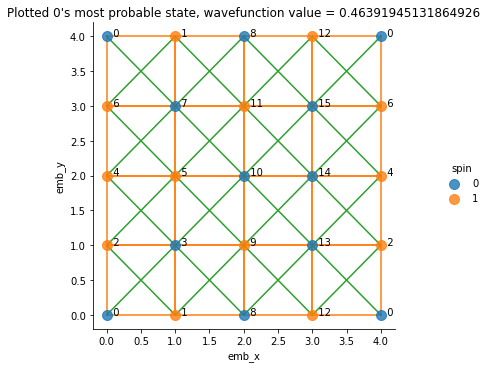

In [115]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True
)
system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

In [116]:
# with and without symmetries should give the same ground state energy
assert np.isclose(system_sym.ground_energy, system_nosym.ground_energy)

#### Reference 4×4

In [117]:
### FROM: https://github.com/twesterhout/nqs-playground/blob/0ba67c9d4ff9f70bbaeea2a9490271dd49ea5091/benchmark/benchmark_apply.py#L9-L20
def load_basis_and_hamiltonian(filename: str, no_symmetries=False, no_inversions=False):
    import yaml

    # logger.info("Loading basis from '{}'...", filename)
    with open(filename, "r") as f:
        config = yaml.load(f, Loader=yaml.SafeLoader)
    if no_symmetries:
        config["basis"]["symmetries"] = []
    if no_inversions:
        del config["basis"]["spin_inversion"]
    basis = ls.SpinBasis.load_from_yaml(config["basis"])
    # logger.info("Loading Hamiltonian from '{}'...", filename)
    hamiltonian = ls.Operator.load_from_yaml(config["hamiltonian"], basis)
    return basis, hamiltonian


### END FROM

```
# Initial layout:
    # - permutation: [ 0,  1,  2,  3,
    #                  4,  5,  6,  7,
    #                  8,  9, 10, 11,
    #                 12, 13, 14, 15]
    #
```

In [118]:
basis, hamiltonian = load_basis_and_hamiltonian(
    "heisenberg_square_4x4.yaml", no_symmetries=True, no_inversions=True
)
eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=1)
assert np.isclose(eigenvalues[0], system_nosym.ground_energy)
# energy coincides with the reference implementation

#### 6×2 lattice 

self.number_spins=12
Symmetry group contains 0 elements
Hilbert space dimension is 462
Ground state energy is -41.2913023078


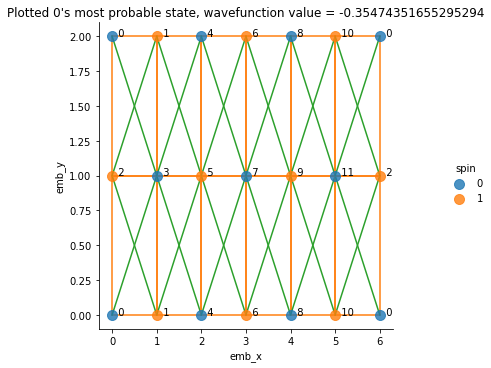

In [119]:
system_nosym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=False
)
system_nosym.get_ground_state()
system_nosym.visualize_probable_configurations(k=0)

The checkerboard, works as expected.

self.number_spins=12
Symmetry group contains 24 elements
Hilbert space dimension is 44
Ground state energy is -41.2913023078


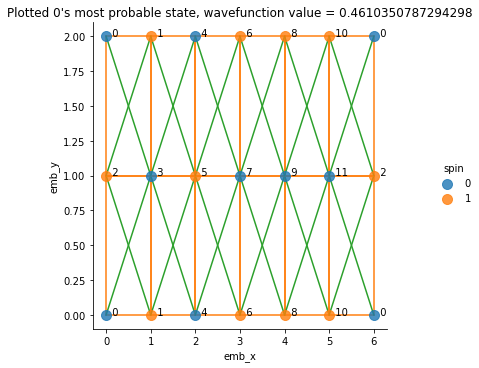

In [120]:
system_sym = HeisenbergJ1J2(
    SquareLattice(width=6, height=2), J1=1, J2=0, use_symmetries=True
)
system_sym.get_ground_state()
system_sym.visualize_probable_configurations(k=0)

### Kagome Lattice

In [121]:
class KagomeLattice(SpinLattice):
    def __init__(self, width=1, height=1):
        """
        Generates Kagome lattice.

        The fundamental domain:

             F -- G -- H
            /      \\ /
           D         E
         /  \\      /
        A -- B -- C

        Size of the fundamental domain is 2×2
        """
        theta = np.pi / 3
        u = np.array([1, 0])
        v = np.array([np.cos(theta), np.sin(theta)])

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([2, 0]),
            "D": np.array([0, 1]),
            "E": np.array([2, 1]),
            "F": np.array([0, 2]),
            "G": np.array([1, 2]),
            "H": np.array([2, 2]),
        }

        named_edges = [
            ("AB", 1),
            ("BC", 1),
            ("AD", 1),
            ("BD", 2),
            ("DF", 1),
            ("FG", 1),
            ("GE", 2),
            ("GH", 1),
            ("EH", 1),
            ("CE", 1),
        ]

        super().__init__(
            u=u,
            v=v,
            named_sites=named_sites,
            named_edges=named_edges,
            fundamental_domain_size=2,
            width=width,
            height=height,
        )

lat.site_to_num.values()=dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 10, 0, 3, 11, 5, 8, 10, 0])
lat.kind_to_edges=defaultdict(<class 'list'>, {1: [(0, 1), (1, 2), (0, 3), (3, 5), (5, 6), (6, 7), (4, 7), (2, 4), (5, 8), (8, 0), (9, 2), (7, 9), (2, 10), (10, 0), (7, 11), (11, 5)], 2: [(1, 3), (6, 4), (6, 8), (1, 9), (10, 4), (11, 3), (11, 9), (10, 8)]})


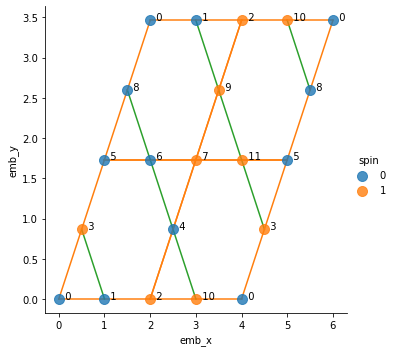

In [122]:
lat = KagomeLattice(width=2, height=2)
lat.plot(spins=np.random.randint(2, size=len(lat.sites)))
assert sorted(set(lat.site_to_num.values())) == list(range(12))
print(f"{lat.site_to_num.values()=}")
print(f"{lat.kind_to_edges=}")
# print(lat.sites_df)

## Canonical basis

In [204]:
system = HeisenbergJ1J2(
    SquareLattice(width=4, height=4), J1=1, J2=0, use_symmetries=True, spin_inversion=1
)
system.get_ground_state()

system_nosym = HeisenbergJ1J2(
    SquareLattice(width=4, height=4),
    J1=1,
    J2=0,
    use_symmetries=False,
    spin_inversion=None,
)
system_nosym.get_ground_state()

self.number_spins=16
Symmetry group contains 128 elements
Hilbert space dimension is 107
Ground state energy is -44.9139328337
self.number_spins=16
Symmetry group contains 0 elements
Hilbert space dimension is 12870
Ground state energy is -44.9139328337


(array([-44.91393283]),
 array([[-0.00075158],
        [-0.00134471],
        [ 0.00087267],
        ...,
        [ 0.00087267],
        [-0.00134471],
        [-0.00075158]]))

In [208]:
assert (
    system_nosym.get_df_ground_state()
    .merge(
        system.get_df_ground_state(canonical_basis=True), on="basis_state", how="outer"
    )
    .assign(
        ok=lambda x: np.isclose(
            x["ground_state_coeff_x"],
            x["ground_state_coeff_y"]
            * np.sign(x["ground_state_coeff_y"])
            * np.sign(x["ground_state_coeff_x"]),
        )
    )["ok"]
    .all()
)